# Creating datasets

A dataset is a file with an extension `.mglyph`. It is a ZIP archive with this structure:

```text
dataset.mglyph
├── manifest.json
├── 0000.png
├── 0001.png
└── ...
```

`manifest.json` has this structure:

```json
{
  "name": "Simple Star",
  "creation_time": "2026-04-15T10:30:00",
  "samples": {
    "0": [
      {
        "x": 12.34,
        "filename": "0000.png",
        "metadata": {}
      }
    ],
    "1": [
      {
        "x": 56.78,
        "filename": "0001.png",
        "metadata": {}
      }
    ]
  }
}
```

Where:
- `samples` maps split IDs to lists of samples (`"0"` and `"1"` in this notebook, but these can be literally anything).
- Each sample points to a PNG filename inside the same archive.
- `x` is the regression label for that image.

In [1]:
import random
from pathlib import Path
from zipfile import ZipFile

import mglyph as mg
import numpy as np

from mglyph_ml.dataset.color import hsl_to_hex
from mglyph_ml.dataset.export import Drawer, export_dataset

# Simple Star

This cell generates a dataset containing a simple star.

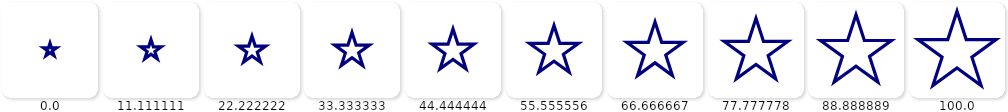

Generated: data/simple-star-20k-dual.mglyph


In [8]:
def star(x: float, canvas: mg.Canvas, bordercolor, fillcolor, linewidth) -> None:
    canvas.tr.translate(0, mg.lerp(x, 0, 0.05))
    radius = mg.lerp(x, 0.15, canvas.ysize / 2 * 0.9)

    vertices = []
    for segment in range(5):
        vertices.append(mg.orbit(canvas.center, segment * 2 * np.pi / 5, radius))
        vertices.append(
            mg.orbit(
                canvas.center,
                (segment + 0.5) * 2 * np.pi / 5,
                np.cos(2 * np.pi / 5) / np.cos(np.pi / 5) * radius,
            )
        )

    canvas.polygon(vertices, linecap="round", style="fill", color=fillcolor)
    canvas.polygon(vertices, width=linewidth, linecap="round", style="stroke", color=bordercolor)


def simple_star() -> Drawer:
    bordercolor = "navy"
    fillcolor = "white"
    linewidth = "70p"
    return lambda x, canvas: star(x, canvas, bordercolor, fillcolor, linewidth)


mg.show(simple_star(), x=list(np.linspace(0, 100, 10)))  # type: ignore

export_dataset("Simple Star", Path("data/simple-star-20k-dual.mglyph"), simple_star(), n_samples=20_000)

# Varying star

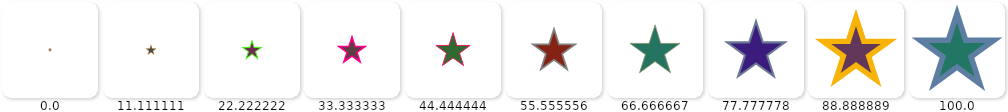

Removed existing data/varying-star-20k-dual.mglyph
Generated: data/varying-star-20k-dual.mglyph


: 

In [ ]:
def varying_star(x: float, canvas: mg.Canvas) -> None:
    canvas.tr.translate(0, mg.lerp(x, 0, 0.05))
    radius = mg.lerp(x, 0.03, canvas.ysize / 2 * 0.85)

    vertices = []
    for segment in range(5):
        vertices.append(mg.orbit(canvas.center, segment * 2 * np.pi / 5, radius))
        vertices.append(
            mg.orbit(
                canvas.center,
                (segment + 0.5) * 2 * np.pi / 5,
                np.cos(2 * np.pi / 5) / np.cos(np.pi / 5) * radius,
            )
        )

    hue = random.randrange(360)
    saturation = random.randrange(100)
    canvas.polygon(vertices, linecap="round", style="fill", color=hsl_to_hex(hue, saturation, 30))

    hue = random.randrange(360)
    saturation = random.randrange(100)
    line_width = random.uniform(0.15, 1.5) * x
    canvas.polygon(
        vertices,
        width=f"{line_width}p",
        linecap="round",
        style="stroke",
        color=hsl_to_hex(hue, saturation, 50),
    )


mg.show(varying_star, x=list(np.linspace(0, 100, 10)))  # type: ignore

export_dataset("Varying Star 20k Dual", Path("data/varying-star-20k-dual.mglyph"), varying_star, n_samples=20000)

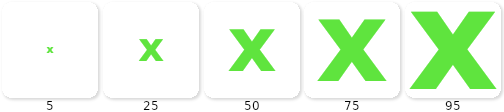

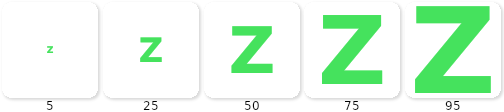

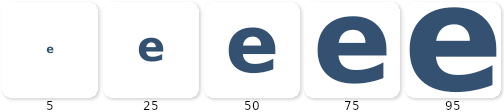

Generated: data/random-letter-10k.mglyph


: 

In [ ]:
def scaled_letter(x: float, canvas: mg.Canvas, color, character) -> None:
    canvas.text(
        character,
        (0, 0),
        "Arial",
        mg.lerp(x, 0.05, 2.0),
        anchor="center",
        color=color,
        font_weight="bold",
        font_slant="upright",
    )


def random_letter() -> Drawer:
    color = tuple(random.random() for _ in range(3))
    character = random.choice(
        "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZěščřžýáíéóúťďňĚŠČŘŽÝÁÍÉÓÚŤĎŇ0123456789"
    )
    return lambda x, canvas: scaled_letter(x, canvas, color, character)


for _ in range(3):
    mg.show(random_letter())  # type: ignore

export_dataset(
    name="Random Letter 10k",
    drawer=random_letter(),
    path=Path("data/random-letter-10k-dual.mglyph"),
    seed=69,
    n_samples=10_000,
)